## Imports

In [15]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Carregamento e EDA


INFO
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB
None

DESCRIBE
         survived      pclass         age       sibsp       parch        

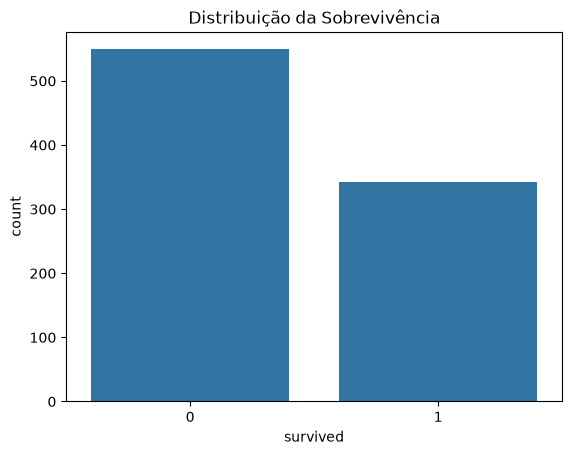

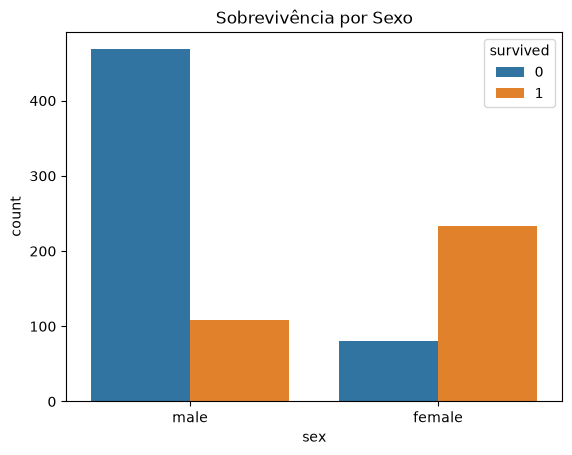

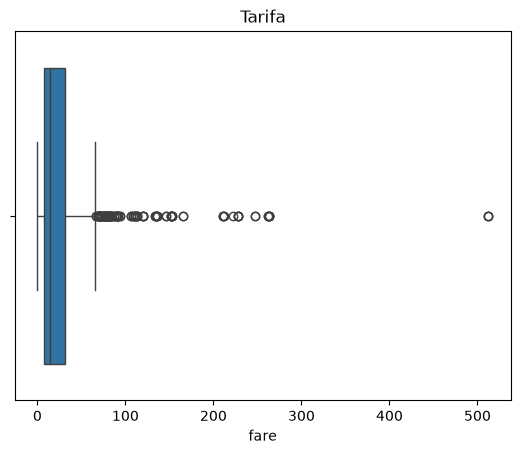

In [16]:
titanic = sns.load_dataset('titanic')

print("\nINFO")
print(titanic.info())

print("\nDESCRIBE")
print(titanic.describe())

print("\nVALORES AUSENTES")
print(titanic.isnull().sum())

# Distribuição da sobrevivência
sns.countplot(data=titanic, x='survived')
plt.title('Distribuição da Sobrevivência')
plt.show()

# Sobrevivência por sexo
sns.countplot(data=titanic, x='sex', hue='survived')
plt.title('Sobrevivência por Sexo')
plt.show()

# Outliers da tarifa
sns.boxplot(x=titanic['fare'])
plt.title('Tarifa')
plt.show()

## Preparação dos dados

In [17]:
features_numericas = ['age', 'fare', 'pclass']
features_categoricas = ['sex', 'embarked']

X_titanic = titanic[
    ['pclass', 'sex', 'age', 'fare', 'embarked']
]

y_titanic = titanic['survived']


## Train-Test split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X_titanic,
    y_titanic,
    test_size=0.2,
    random_state=42,
    stratify=y_titanic
)

## Pré-processamento

In [19]:
transformador_numerico = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

transformador_categorico = Pipeline([
    ('imputer', SimpleImputer(
        strategy='constant',
        fill_value='missing'
    )),
    ('onehot', OneHotEncoder(
        handle_unknown='ignore'
    ))
])

preprocessor = ColumnTransformer([
    ('num', transformador_numerico, features_numericas),
    ('cat', transformador_categorico, features_categoricas)
])


## Random forest

In [20]:
pipe_titanic = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        random_state=42
    ))
])

param_grid_titanic = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [3, 5, 7],
    'preprocessor__num__imputer__strategy': [
        'mean',
        'median'
    ]
}

grid_titanic = GridSearchCV(
    pipe_titanic,
    param_grid_titanic,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_titanic.fit(X_train, y_train)

best_model = grid_titanic.best_estimator_

## Predição

In [21]:
y_pred = best_model.predict(X_test)

## Matriz de confusão

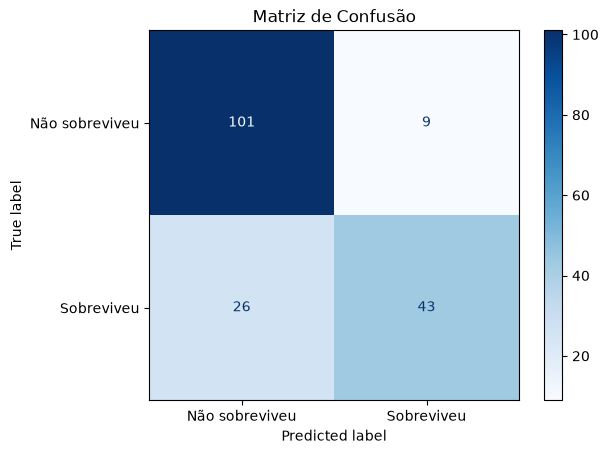

In [22]:
ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    display_labels=[
        "Não sobreviveu",
        "Sobreviveu"
    ],
    cmap="Blues"
)

plt.title("Matriz de Confusão")
plt.show()

## Classification report

In [23]:
print("\nCLASSIFICATION REPORT")
print(classification_report(
    y_test,
    y_pred
))


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.80      0.92      0.85       110
           1       0.83      0.62      0.71        69

    accuracy                           0.80       179
   macro avg       0.81      0.77      0.78       179
weighted avg       0.81      0.80      0.80       179



## Curva ROC

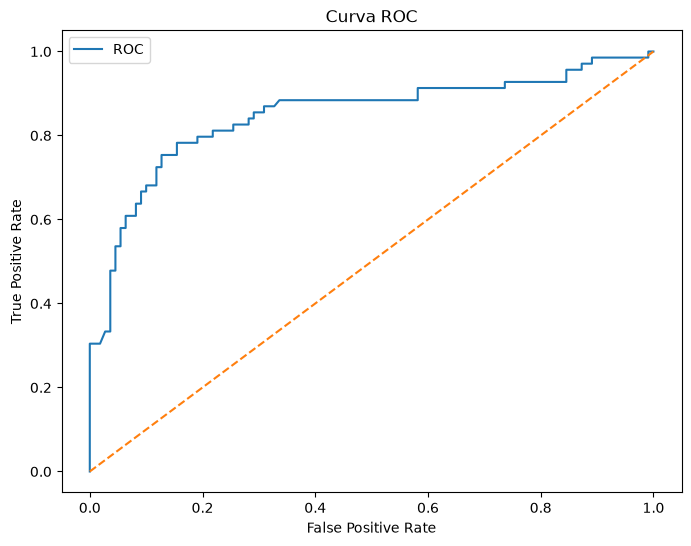

In [24]:
y_prob = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label='ROC')
plt.plot([0,1], [0,1], '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()
plt.show()

## ROC AUC

In [25]:
roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("\nROC-AUC:", roc_auc)


ROC-AUC: 0.8482872200263505


## Importância das features


IMPORTÂNCIA DAS FEATURES
                 feature  importance
1              num__fare    0.235495
3        cat__sex_female    0.221543
0               num__age    0.194909
4          cat__sex_male    0.184648
2            num__pclass    0.122050
7        cat__embarked_S    0.019378
5        cat__embarked_C    0.012685
6        cat__embarked_Q    0.009095
8  cat__embarked_missing    0.000197


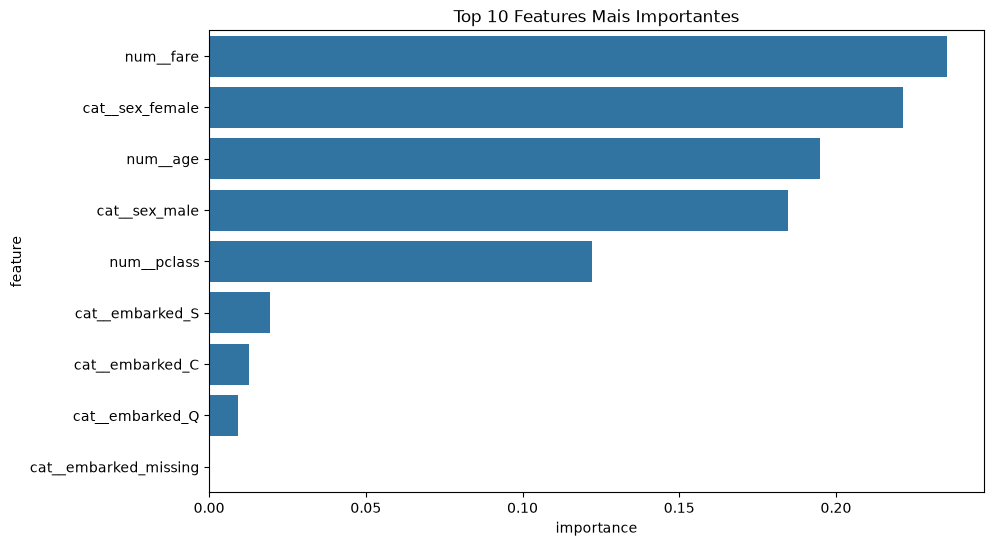

In [26]:
feature_names = best_model.named_steps[
    'preprocessor'
].get_feature_names_out()

importancias = best_model.named_steps[
    'classifier'
].feature_importances_

importancias_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importancias
})

importancias_df = importancias_df.sort_values(
    by='importance',
    ascending=False
)

print("\nIMPORTÂNCIA DAS FEATURES")
print(importancias_df)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importancias_df.head(10),
    x='importance',
    y='feature'
)

plt.title('Top 10 Features Mais Importantes')
plt.show()

## Overfitting/Underfitting

In [27]:
train_score = best_model.score(
    X_train,
    y_train
)

test_score = best_model.score(
    X_test,
    y_test
)

print("\nAccuracy Treino:", train_score)
print("Accuracy Teste:", test_score)


Accuracy Treino: 0.9143258426966292
Accuracy Teste: 0.8044692737430168


## Grid search resultados

In [28]:
print("\nMelhores parâmetros:")
print(grid_titanic.best_params_)

print("\nMelhor acurácia CV:")
print(grid_titanic.best_score_)


Melhores parâmetros:
{'classifier__max_depth': 7, 'classifier__n_estimators': 50, 'preprocessor__num__imputer__strategy': 'median'}

Melhor acurácia CV:
0.8301585738205457
